# 05 — Prompt Ablation Study: melyik komponens ad valódi értéket?

A hosszabb prompt könnyen tűnhet „profibbnak”, de ettől még nem biztos, hogy jobb. Az ablation study célja, hogy a teljes promptból **egy komponenst egyszerre eltávolítsunk**, és megnézzük, romlik-e a mérhető teljesítmény.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: <PROJECT_ROOT>


## Provider és ablation

Az ablation ugyanazzal a provider/model párossal fusson, mint a fő benchmark. Így a `FULL - component` különbség ténylegesen a promptkomponens hatását méri.


In [2]:
import os
PROVIDER = os.getenv("LLM_PROVIDER", "mock")
print("Ablation provider:", PROVIDER)


Ablation provider: mock


## 1. Miért development seten fut az ablation?

Az ablation iteratív promptfejlesztés. Ha ezt a final holdouton végeznénk, ugyanúgy test-set tuningot végeznénk, mint amikor ML-modell hyperparamétereit a teszthalmazon választjuk ki.

**Döntés:** minden ablation a `development.csv` adaton fut.

## 2. Vizsgált komponensek

A `full` változat tartalmazza:

- label definitions;
- few-shot examples;
- explicit constraints;
- decision policy.

Ezután egyesével eltávolítjuk őket.

In [3]:
variants = [
    ["full", "definitions + few-shot + constraints + decision policy"],
    ["minus_definitions", "remove label semantics"],
    ["minus_few_shot", "remove demonstrations"],
    ["minus_constraints", "remove explicit behavioural rules"],
    ["minus_decision_policy", "remove routing policy"],
]

import pandas as pd
pd.DataFrame(variants, columns=["variant", "change"])


,variant,change
0,full,definitions + few-shot + constraints + decisio...
1,minus_definitions,remove label semantics
2,minus_few_shot,remove demonstrations
3,minus_constraints,remove explicit behavioural rules
4,minus_decision_policy,remove routing policy


## 3. Mit várunk?

Az ablation értelmezése:

- ha egy komponens eltávolítása jelentősen csökkenti az F1-et, valószínűleg hasznos;
- ha az F1 változatlan, de token/cost csökken, a komponens production szempontból kérdéses;
- ha az F1 javul eltávolítás után, a komponens akár káros is lehet.

Ez a **prompt parsimony** elve: csak az maradjon, ami mérhetően indokolt.

## 4. Futtatás

In [4]:
print("Offline:")
print("python 05_scripts/05_run_ablation.py --provider mock --force")
print("\nReal API:")
print("python 05_scripts/05_run_ablation.py --provider openai")


Offline:
python 05_scripts/05_run_ablation.py --provider mock --force

Real API:
python 05_scripts/05_run_ablation.py --provider openai


## 5. Ablation results betöltése

In [5]:
results_path = PROJECT_ROOT / "07_outputs/results" / PROVIDER / "ablation_results.csv"
if not results_path.exists():
    raise FileNotFoundError("Run 05_scripts/05_run_ablation.py first.")

ablation = pd.read_csv(results_path)
display(ablation.sort_values("macro_f1", ascending=False))


,provider,model,strategy,requests,correct_count,incorrect_count,invalid_output_count,api_error_count,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,invalid_output_rate,output_contract_valid_rate,invalid_json_rate,json_grammar_valid_rate,error_rate,mean_input_tokens,mean_output_tokens,mean_total_tokens,total_input_tokens,total_output_tokens,total_tokens,tokens_per_correct_prediction,mean_latency_seconds,median_latency_seconds,p50_latency_seconds,p95_latency_seconds,p99_latency_seconds,total_latency_seconds,sequential_throughput_rps,mean_cost_usd,cost_per_1000_requests_usd,benchmark_cost_usd,cost_per_correct_prediction_usd,mean_branch_count
0,mock,mock-prompt-sensitive-simulator-v2,minus_constraints,300.0,220.0,80.0,5.0,0.0,0.733333,0.769537,0.733333,0.743811,0.743811,0.016667,0.983333,NaN,NaN,0.0,1243.793333,1.116667,1244.910000,373138.0,335.0,373473.0,1697.604545,0.785660,0.78540,0.78540,0.817515,0.828206,235.6979,1.272816,0.0,0.0,0.0,0.0,1.0
1,mock,mock-prompt-sensitive-simulator-v2,minus_definitions,300.0,210.0,90.0,14.0,0.0,0.700000,0.760479,0.700000,0.722053,0.722053,0.046667,0.953333,NaN,NaN,0.0,1177.246667,1.326667,1178.573333,353174.0,398.0,353572.0,1683.676190,0.756003,0.75480,0.75480,0.787900,0.794533,226.8008,1.322747,0.0,0.0,0.0,0.0,1.0
2,mock,mock-prompt-sensitive-simulator-v2,minus_few_shot,300.0,210.0,90.0,12.0,0.0,0.700000,0.752820,0.700000,0.719019,0.719019,0.040000,0.960000,NaN,NaN,0.0,441.246667,1.280000,442.526667,132374.0,384.0,132758.0,632.180952,0.448898,0.44885,0.44885,0.481705,0.484609,134.6695,2.227676,0.0,0.0,0.0,0.0,1.0
3,mock,mock-prompt-sensitive-simulator-v2,minus_decision_policy,300.0,202.0,98.0,16.0,0.0,0.673333,0.746304,0.673333,0.697513,0.697513,0.053333,0.946667,NaN,NaN,0.0,1186.206667,1.373333,1187.580000,355862.0,412.0,356274.0,1763.732673,0.761979,0.76050,0.76050,0.793215,0.801507,228.5938,1.312372,0.0,0.0,0.0,0.0,1.0
4,mock,mock-prompt-sensitive-simulator-v2,full,300.0,197.0,103.0,9.0,0.0,0.656667,0.708507,0.656667,0.674607,0.674607,0.030000,0.970000,NaN,NaN,0.0,1320.653333,1.210000,1321.863333,396196.0,363.0,396559.0,2012.989848,0.818011,0.81910,0.81910,0.850515,0.855002,245.4032,1.222478,0.0,0.0,0.0,0.0,1.0


## 6. Macro F1 vizualizáció

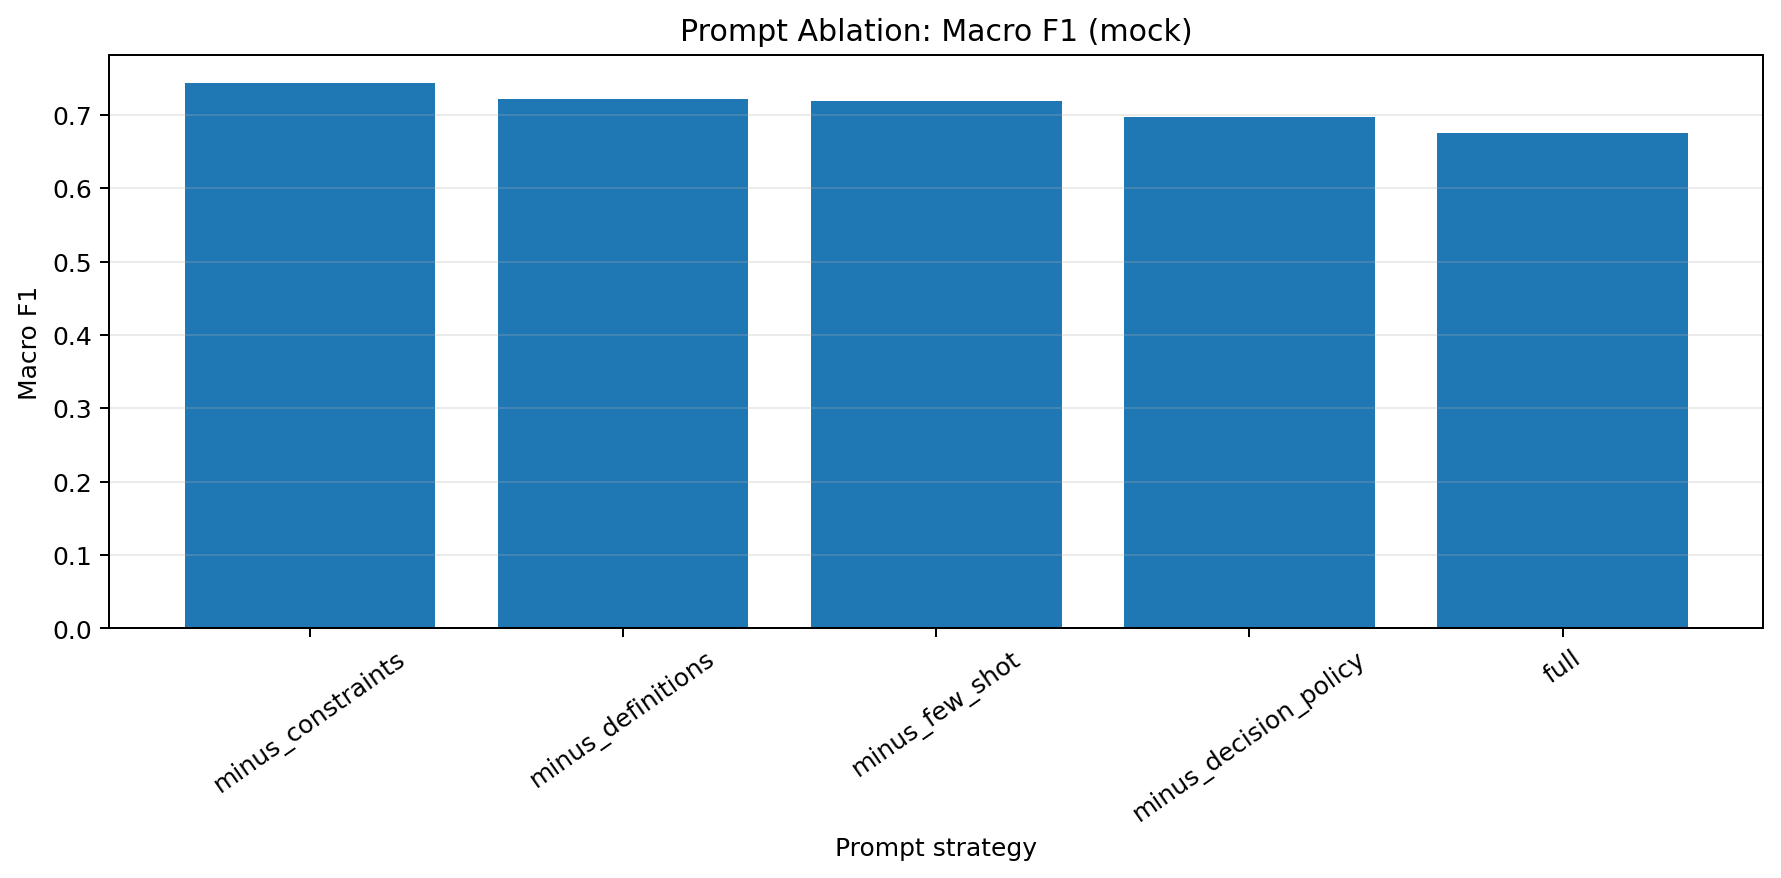

In [6]:
from IPython.display import Image, display

path = PROJECT_ROOT / "07_outputs/reports/figures" / PROVIDER / "ablation_macro_f1.png"
if path.exists():
    display(Image(filename=str(path)))


## 7. Delta a full prompthoz képest

A nyers score helyett közvetlenül azt nézzük, mennyit változik az F1, ha kivesszük az adott komponenst.

In [7]:
full_row = ablation[ablation["strategy"] == "full"]
if not full_row.empty:
    full_f1 = float(full_row.iloc[0]["macro_f1"])
    ablation["delta_macro_f1_vs_full"] = ablation["macro_f1"] - full_f1
    display(ablation[["strategy", "macro_f1", "delta_macro_f1_vs_full", "mean_total_tokens", "cost_per_1000_requests_usd", "p95_latency_seconds"]])


,strategy,macro_f1,delta_macro_f1_vs_full,mean_total_tokens,cost_per_1000_requests_usd,p95_latency_seconds
0,minus_constraints,0.743811,0.069204,1244.910000,0.0,0.817515
1,minus_definitions,0.722053,0.047447,1178.573333,0.0,0.787900
2,minus_few_shot,0.719019,0.044413,442.526667,0.0,0.481705
3,minus_decision_policy,0.697513,0.022907,1187.580000,0.0,0.793215
4,full,0.674607,0.000000,1321.863333,0.0,0.850515


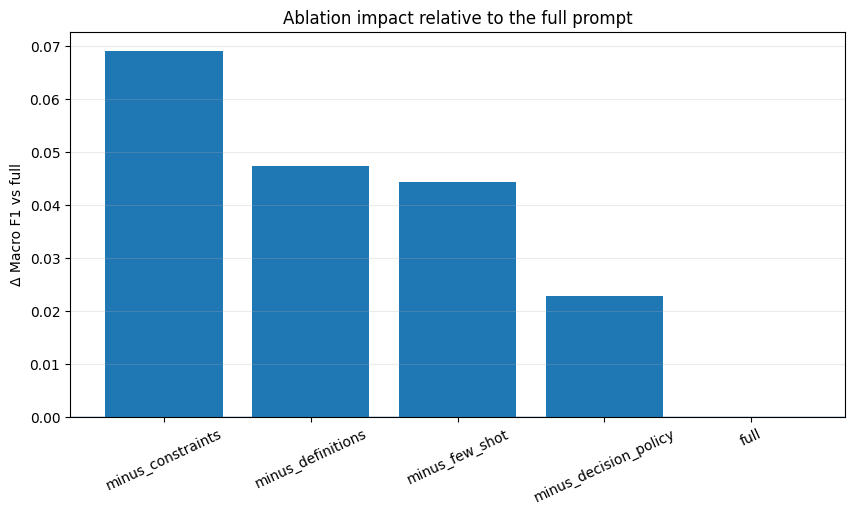

In [8]:
if "delta_macro_f1_vs_full" in ablation.columns:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ablation["strategy"], ablation["delta_macro_f1_vs_full"])
    ax.axhline(0, linewidth=1)
    ax.set_title("Ablation impact relative to the full prompt")
    ax.set_ylabel("Δ Macro F1 vs full")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)
    plt.show()


## 8. Quality vs prompt cost

A komponens akkor különösen értékes, ha mérhető F1-et ad **kis tokenoverhead mellett**. Few-shot például gyakran nagyobb kontextust okoz, ezért még akkor is meg kell nézni a cost trade-offot, ha javítja a minőséget.

In [9]:
display(ablation[["strategy", "macro_f1", "mean_input_tokens", "mean_output_tokens", "cost_per_1000_requests_usd", "p95_latency_seconds"]].sort_values("macro_f1", ascending=False))


,strategy,macro_f1,mean_input_tokens,mean_output_tokens,cost_per_1000_requests_usd,p95_latency_seconds
0,minus_constraints,0.743811,1243.793333,1.116667,0.0,0.817515
1,minus_definitions,0.722053,1177.246667,1.326667,0.0,0.787900
2,minus_few_shot,0.719019,441.246667,1.280000,0.0,0.481705
3,minus_decision_policy,0.697513,1186.206667,1.373333,0.0,0.793215
4,full,0.674607,1320.653333,1.210000,0.0,0.850515


## 9. Hogyan hozunk döntést az ablation alapján?

Például:

- `minus_few_shot` ≈ full F1, de sokkal kevesebb token → few-shot elhagyható;
- `minus_definitions` jelentősen rosszabb F1 → definitions marad;
- `minus_constraints` azonos F1, de több invalid output → constraints reliability miatt maradhat;
- `minus_policy` jobb F1 → a policy valószínűleg túl agresszív vagy hibás határt kódol.

A valós következtetést mindig a mért adatok alapján írd le, ne előre.

## 10. Miért erős portfólióelem az ablation?

Mert bizonyítja, hogy nem „promptot díszítünk”, hanem **komponens-szintű kísérletet** végzünk. Ez közelebb áll az ML feature ablation és software performance profiling szemléletéhez.